# Shapley Values

In this notebook we will try to understand how a pre-trained model makes its predictions using the SHAP (SHapley Additive exPlanations) library. The Tree model was trained to predict survival probability of passengers on the titanic. We will analyze the model by generating several plots that combine Shapley values at different resolutions. Your job is to read the [documentation](https://shap.readthedocs.io/en/latest/index.html), and interpret each of the generated plots. 

In [1]:
# Load the necessary libraries

import shap # For SHAP plots
import joblib # For loading the model
import pandas as pd # For data manipulation
shap.initjs() # Initialize JavaScript for SHAP visualizations
import warnings # Mute all errors
warnings.filterwarnings("ignore")

c:\Users\aaron\miniconda3\envs\ml-bachelor-eai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the pre-trained model
# This model is a scikit-learn pipeline that takes raw data and outputs a prediction.
# The model predicts a survival score
# where a higher score means a higher chance of survival.
model = joblib.load('../models/titanic_model.pkl')

# Load the data
# We load the same data the model was trained on to analyze its behavior.
# This dataset contains information about the passengers on the Titanic.
# It does not include the survival outcome, however this target was used during training.
data = pd.read_csv('../data/titanic_data.csv')
data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,7.2500,2.0
1,1,0,38.0,1,0,71.2833,0.0
2,3,0,26.0,0,0,7.9250,2.0
3,1,0,35.0,1,0,53.1000,2.0
4,3,1,35.0,0,0,8.0500,2.0


### 2: Preparing the Data and Creating the SHAP Explainer

The SHAP library needs two main things to explain a model's predictions:

- The Model: The prediction logic we want to explain.

- The Data: A set of examples to run through the model for explanation.

We will use the modern shap.Explainer interface, which automatically selects the best explainer type, in this case the fast TreeExplainer behind the scenes.

In [3]:
# We'll use all our data for the explanation, but in practice, a representative
# sample (e.g., 100-1000 rows) is often sufficient and much faster.
X = data

# 1. Create a SHAP explainer object
# We pass the model and the data to the explainer.
# The explainer learns the model's behavior based on the data provided.
explainer = shap.Explainer(model, X)

# 2. Calculate SHAP values
# This computes the SHAP value for each feature for each prediction.
# The output is a special 'Explanation' object that contains the values,
# the original data, feature names, and more.
shap_values = explainer(X)

print("SHAP values have been calculated.")
print(shap_values.shape) # (num_samples, num_features)

SHAP values have been calculated.
(891, 7)


### 3: Global Feature Importance - The "Big Picture"

Global explanations help us understand the model's behavior as a whole, across all predictions. We can answer questions like, "What features are most important to the model overall?" This is a global explanation. This is the simplest way to see which features have the biggest impact on the model's predictions. 

***Bar plot***

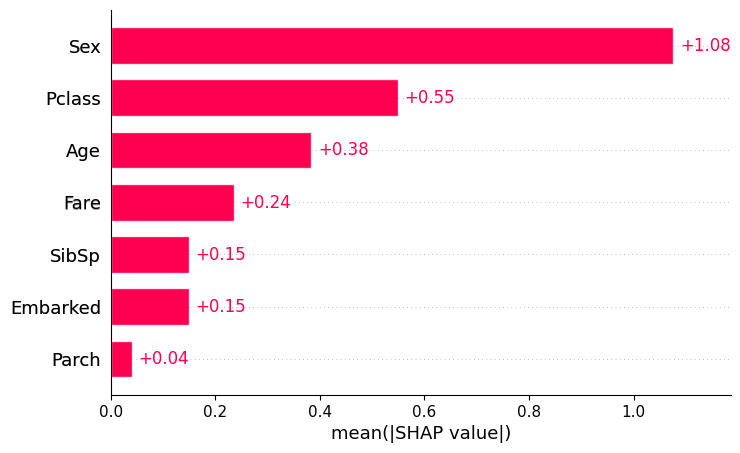

In [4]:
shap.plots.bar(shap_values)

What I notice right away is that Sex dominates by a large margin — the model is leaning on it heavily across almost all passengers. Pclass and Age come next but are noticeably smaller. The chart only shows average magnitude, not direction — I can't tell from this alone whether a high Sex value increases or decreases survival, for that I need the beeswarm.

***Beeswarm Plot*** (Summary Plot)

The beeswarm plot is much richer than the bar plot. It shows not only the importance of each feature but also how the value of that feature affects the prediction.

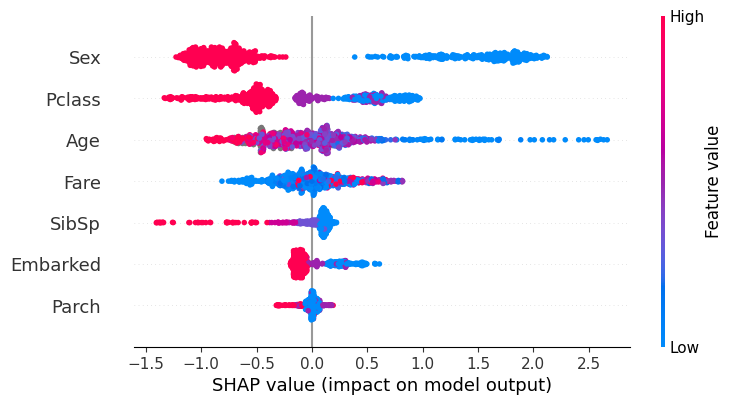

In [5]:
shap.plots.beeswarm(shap_values)

Each dot is one passenger — horizontal position shows how much that feature pushed the prediction up (right) or down (left), color shows the actual feature value (red = high, blue = low). For Sex I can see the blue dots (female, Sex=0) cluster strongly to the right, meaning being female increases predicted survival a lot. The red dots (male) do the opposite, which matches the "women and children first" idea. For Pclass I notice the same pattern — blue (first class) pushes right, red (third class) pushes left. If I had to pick the worst combination it would be male, third class, older age; the best would be female, first class, young.

### 4. Local Explanations - Explaining a Single Prediction

We now zoom in and explain how the model arrived at its prediction for one specific person. This is called a local explanation.

***Waterfall Plot***

The waterfall plot breaks down a single prediction, showing how each feature's contribution moves the prediction from the "base value" to the final score.

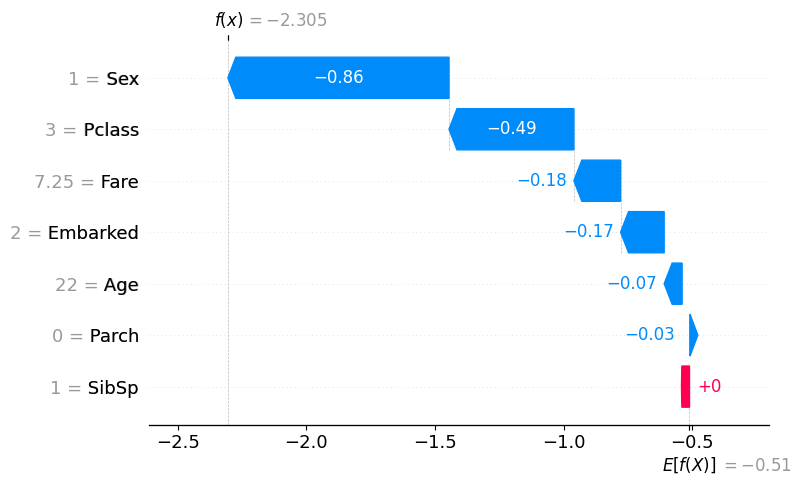

In [6]:
shap.plots.waterfall(shap_values[0])

Passenger 0 is a 22-year-old male in third class. Looking at the waterfall I can see that Sex and Pclass both push the prediction down from the base value (E[f(x)]), just like the beeswarm showed. The final prediction ends up clearly below the average survival probability. Age has a smaller effect here — 22 is young so it doesn't hurt as much as the gender and class do.

### 5: Feature Interaction Effects

Sometimes, the effect of one feature depends on the value of another. This is something our ICE and PDP plots could not reveal, however, SHAP can help us uncover these relationships.

***Dependence Plot*** (Scatter Plot)

A dependence plot shows how the value of a single feature impacts its SHAP value. We can color it by another feature to discover interactions.

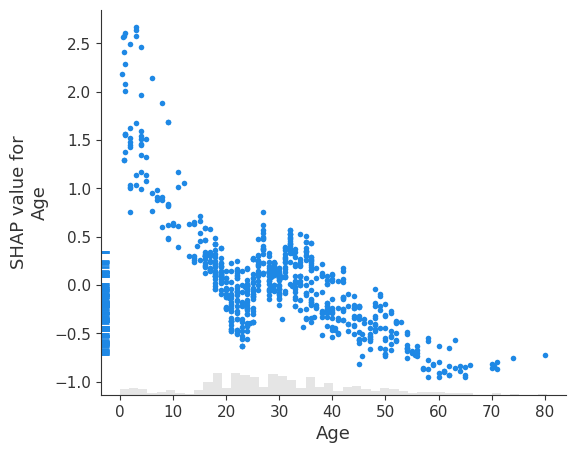

In [7]:
shap.plots.scatter(shap_values[:, "Age"])

The x-axis is the actual age of the passenger and the y-axis is the SHAP value for Age — above zero means age is pushing toward survival, below zero means it's hurting. The color is automatically chosen by SHAP as the feature that interacts most with Age, which I think is Sex. What I find interesting is that the two colors split into two bands — for the same age, females tend to have a higher SHAP value than males, showing a real interaction between the two. Overall there's a slight downward trend so older passengers generally get a lower survival prediction, just not as strongly as Sex or Pclass.